# DG 1D code from scratch

A Python Implementation of the Discontinuous Galerkin Method for 1D Scalar Hyperbolic Conservation Laws.

Reference: [Shu, Chi-Wang. “Discontinuous Galerkin Methods: General Approach and Stability.” (2008).](https://www.semanticscholar.org/paper/Discontinuous-Galerkin-Methods%3A-General-Approach-Shu/3634ba12cf794b99e52bd9782d40372211669c5b?utm_source=direct_link)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import legendre
import pandas as pd

plt.rcParams.update(
    {
        "savefig.dpi": 300,
        "figure.autolayout": True,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "lines.linewidth": 1.0,
        "lines.markersize": 5,
        "axes.linewidth": 1.0,
        "lines.markerfacecolor": "none",
        "lines.markeredgecolor": "auto",
        "xtick.direction": "in",
        "ytick.direction": "in",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.framealpha": 1.0,
    }
)

# Burgers equation

For the conservation law equation
$$
u_t + f(u)_x = 0
$$
taking $f(u) = \frac{u^2}2$ yields the Burgers equation:
$$
u_t + \left(\frac12 u^2\right)_x = 0
$$

For the Burgers equation, the characteristic line $l_\xi$ passing through the point $(\xi,0)$ is given by
$$
x = \xi + u_0(\xi) t
$$
The exact solution $u$ remains constant along the characteristic line: $u(x,t) = u_0(\xi)$。

Therefore:

- If there is a unique characteristic line $l_\xi$ passing through the point $(x,t)$, then $u(x,t) = u_0(\xi)$ is the unique root of the following nonlinear equation, which can be solved using Newton's method
    $$
    G(u) = u - u_0(x - u t)
    $$  
- If multiple characteristic lines pass through $(x,t)$, the nonlinear equation above has multiple roots, but only one corresponds to the correct physical solution. A suitable initial guess is necessary to ensure convergence to the valid root.
- If no characteristic line passes through $(x,t)$, then the nonlinear equation has no solution, and the method of characteristics fails to apply. This corresponds to a rarefaction wave region.

Consider the Burgers equation with the initial value:
$$
\left\{
\begin{aligned}
u_t + \left(\frac{u^2}2\right)_x &= 0, \quad x \in [x_l,x_r]\\
u(x,0) &= \alpha + \beta \sin(wx+\phi), \quad w = \frac{2\pi}{x_r - x_l}, \beta > 0
\end{aligned}
\right.
$$
where periodic boundary conditions are imposed.

The solution $u(x,t)$ has the following form:
$$
u(x,t) = \alpha + \beta \,\widetilde{u}(w x + \phi -\alpha w t,\beta  w t)
$$
where $\widetilde{u}$ is the solution to the sine wave initial value problem on the interval $[-\pi, \pi]$:
$$
\left\{
\begin{aligned}
\widetilde{u}_t + \left(\frac{\widetilde{u}^2}2\right)_x &= 0\\
\widetilde{u}(x,0) &= \sin(x)
\end{aligned}
\right.
$$

For this sine-wave initial value problem, the corresponding nonlinear equation for $G(u) = 0$ takes the form:
$$
G(u) = u - \sin(x - u t)
$$
The Newton iteration formula is given by:
$$
u^{(n+1)} = u^{(n)} - \frac{G(u^{(n)})}{G'(u^{(n)})} = u^{(n)} - \frac{u^{(n)} - \sin(x - u^{(n)} t)}{1 - \cos(x - u^{(n)} t) t}
$$

A suitable initial guess at position $(x, t)$ is:
$$
u^{(0)} = \frac{x}{\pi/2+t}, \quad x \in [-\pi,\pi]
$$

In [2]:
def burgers_f(u):
    return u**2 / 2


def burgers_df(u):
    return u

In [3]:
def burgers_sin_solver_kernel(x, t):
    u = x / (np.pi / 2 + t)  # u0

    # Newton iteration
    for _ in range(100000):
        du = (u - np.sin(x - u * t)) / (1 + np.cos(x - u * t) * t)
        u = u - du

        if np.max(np.abs(du)) < 1e-10:
            break

    return u


def burgers_sin_solver(x, t, a, b, w, phi):
    x_tilde = w * x + phi - a * w * t
    x_tilde = np.mod(x_tilde + np.pi, 2 * np.pi) - np.pi  # in [-pi, pi]
    t_tilde = b * w * t

    return a + b * burgers_sin_solver_kernel(x_tilde, t_tilde)

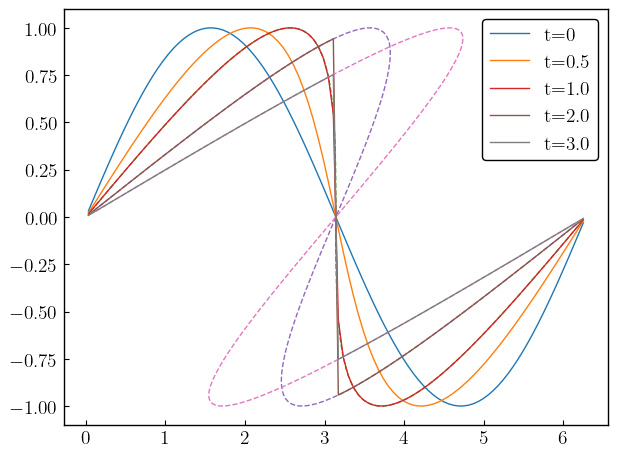

In [4]:
fig, ax = plt.subplots()

for tend in [0, 0.5, 1.0, 2.0, 3.0]:
    x, dx = np.linspace(0, 2 * np.pi, 100, endpoint=False, retstep=True)
    x += dx / 2

    u = burgers_sin_solver(x, tend, a=0.0, b=1.0, w=1.0, phi=0)

    if tend >= 1.0:
        u0 = lambda s: np.sin(s)
        plt.plot(x + u0(x) * tend, u0(x), "--")

    plt.plot(x, u, label=f"t={tend}")

plt.legend()

# SSP-RK3

For the ODE problem $u_t = L(u,t)$, the Strong Stability Preserving Runge-Kutta of order 3 time discretization is given by:
$$
\begin{aligned}
u^{(1)} &= u^n + \Delta t\, L(u^n, t^n) \\ 
u^{(2)} &= \frac34 u^n + \frac14 \left(u^{(1)} + \Delta t\, L(u^{(1)}, t^n + \Delta t)\right) \\ 
u^{n+1} &= \frac13 u^n + \frac23 \left(u^{(2)} +  \Delta t\, L(u^{(2)}, t^n + \frac{\Delta t}2)\right) \\ 
\end{aligned}
$$

When a post-processing operator is applied after each Runge-Kutta stage, the time discretization becomes:
$$
\begin{aligned}
u^{(1)} &= P\left(u^n + \Delta t\, L(u^n, t^n)\right), \\
u^{(2)} &= P\left(\frac34 u^n + \frac14 \left(u^{(1)} + \Delta t\, L(u^{(1)}, t^n + \Delta t)\right)\right), \\
u^{n+1} &= P\left(\frac13 u^n + \frac23 \left(u^{(2)} +  \Delta t\, L(u^{(2)}, t^n + \frac{\Delta t}2)\right)\right),
\end{aligned}
$$

In [5]:
def SSP_RK3_with_post_process(u, t, dt, op_L, post_process, **kwargs):
    u1_pre = u + dt * op_L(u, t, **kwargs)
    u1 = post_process(u1_pre)
    u2_pre = 3 / 4 * u + 1 / 4 * (u1 + dt * op_L(u1, t + dt, **kwargs))
    u2 = post_process(u2_pre)
    unew_pre = 1 / 3 * u + 2 / 3 * (u2 + dt * op_L(u2, t + dt / 2, **kwargs))
    unew = post_process(unew_pre)

    return unew

# LF flux

Lax Friedrichs flux
$$
f^{LF}(u^-,u^+) = \frac{1}{2} \left( f(u^-) + f(u^+) \right) - \frac{\alpha}{2}(u^+ - u^-),\quad \alpha = \max |f'(u)|
$$

For $f(u) = \frac{1}{2}u^2$, since the flux derivative $f'(u) = u$ is monotonic, the local maximum wave speed $\alpha$ can be determined solely based on the endpoint values.  
$$
\alpha = \max(|f'(u^-)|, |f'(u^+)|)
$$

In [6]:
def get_LF_flux(f, get_alpha):
    def fhat_lf(ul, ur):
        return (f(ul) + f(ur)) / 2 - get_alpha(ul, ur) / 2 * (ur - ul)

    return fhat_lf


def burgers_get_alpha(ul, ur):
    return np.maximum(np.abs(burgers_df(ul)), np.abs(burgers_df(ur)))

# Gaussian quadrature

The Gaussian quadrature formula on the standard interval $[-1, 1]$ takes the form
$$
\int_{-1}^1 g(\xi)\,d\xi \approx \sum_{i=1}^{k_g} w_i g(\xi_i)
$$
where $\{ \xi_i \}$ and $\{ w_i \}$ denote the quadrature nodes and corresponding weights, respectively.

To apply Gaussian quadrature over a general interval $[x_l, x_r]$, a change of variables yields the following numerical integration formula: 
$$
\int_{x_l}^{x_r} f(x) dx \approx \frac{x_r-x_l}2 \sum_{i=1}^{k_g} w_i f(x_i),\quad x_i = \frac{x_l + x_r}{2} + \frac{x_r - x_l}{2} \xi_i
$$

In [7]:
def gauss_quadrature(f, xl, xr, gk):
    x = (xl + xr) / 2
    dx = xr - xl

    scalar_flag = np.isscalar(x)
    x = np.atleast_1d(x)  # (n,)

    points, weights = legendre.leggauss(gk)  # (gk,), (gk,)

    x_nodes = x[:, np.newaxis] + dx / 2 * points  # (n, np.newaxis) + (gk,) = (n, gk)
    integral_values = f(x_nodes) * weights  # (n, gk) * (gk,) = (n, gk)
    result = dx / 2 * np.sum(integral_values, axis=1)  # (n,)

    # (n,) or scalar
    return result if not scalar_flag else result[0]

Let $p_0, p_1, \dots, p_k$ denote the Legendre polynomials defined on the interval $[-1, 1]$, 
which serve as the basis functions:
$$
p_0(\xi) = 1, \quad p_1(\xi) = \xi, \quad p_2(\xi) = \frac{1}{2}(3\xi^2 - 1), \quad \dots
$$

For a single point $\xi \in [-1, 1]$, the values of the first $k+1$ basis functions form a vector:
$$
\begin{bmatrix}
p_0(\xi) &
p_1(\xi) &
\cdots &
p_k(\xi)
\end{bmatrix}
\in \mathbb{R}^{k+1}
$$

Given a vector of points $\vec{\xi} \in [-1, 1]^n$, the values of the first $k+1$ basis functions evaluated at these points form a matrix:
$$
M = 
\begin{bmatrix}
p_0(\xi_1) & p_0(\xi_2) & \cdots & p_0(\xi_n) \\ 
p_0(\xi_1) & p_1(\xi_2) & \cdots & p_1(\xi_n) \\  
\vdots & \vdots & \ddots & \vdots \\
p_k(\xi_1) & p_k(\xi_2) & \cdots & p_k(\xi_n)   
\end{bmatrix}
\in \mathbb{R}^{(k+1) \times n}
$$ 

In [8]:
def basis_eval(k, points):
    scalar_flag = np.isscalar(points)
    points = np.atleast_1d(points)

    coeff = np.identity(k + 1)
    result = np.zeros((k + 1, len(points)))

    for i in range(k + 1):
        result[i] = legendre.Legendre(coeff[i])(points)

    # shape = (k+1, len(points)) or (k+1,) if scalar_flag
    return result[:, 0] if scalar_flag else result


We also require the derivatives of the basis functions, namely the values of $p'_0(\xi_i), p'_1(\xi_i), \cdots, p'_k(\xi_i)$.

For a single point $\xi \in [-1, 1]$, the derivatives of the first $k+1$ basis functions form a vector:

$$
\begin{bmatrix}
p'_0(\xi) &
p'_1(\xi) &
\cdots &
p'_k(\xi)
\end{bmatrix}
\in \mathbb{R}^{k+1}
$$

Given a vector of points $\vec{\xi} \in [-1, 1]^n$, the derivatives of the first $k+1$ basis functions evaluated at these points form a matrix:

$$
D = 
\begin{bmatrix}
p'_0(\xi_1) & p'_0(\xi_2) & \cdots & p'_0(\xi_n) \\ 
p'_0(\xi_1) & p'_1(\xi_2) & \cdots & p'_1(\xi_n) \\  
\vdots & \vdots & \ddots & \vdots \\
p'_k(\xi_1) & p'_k(\xi_2) & \cdots & p'_k(\xi_n)  
\end{bmatrix}
\in \mathbb{R}^{(k+1) \times n}
$$


The following recurrence relation is often used to compute the derivatives of Legendre polynomials:

$$
p'_n(\xi) = \frac{n}{\xi^2-1} (p_{n}(\xi) - p_{n-1}(\xi)), \quad n \ge 1
$$

However, this formula is not valid at the endpoints $\xi = \pm 1$.


Note that these derivatives are taken with respect to $\xi$, not with respect to the physical variable $x$. The chain rule gives

$$
\partial_x p_i(\frac{x-x_i}{h/2}) = \frac{2}{h} p'_i(\frac{x-x_i}{h/2})
$$

In [9]:
def basis_dx_eval(k, points):
    scalar_flag = np.isscalar(points)
    points = np.atleast_1d(points)

    coeff = np.identity(k + 1)
    result = np.zeros((k + 1, len(points)))

    for i in range(1, k + 1):
        f1 = legendre.Legendre(coeff[i])
        f2 = legendre.Legendre(coeff[i - 1])
        result[i] = i / (points**2 - 1) * (points * f1(points) - f2(points))

    # shape = (k+1, len(points)) or (k+1,) if scalar_flag
    return result[:, 0] if scalar_flag else result

We need to compute the inner products of this set of orthogonal basis functions. The exact result is given by

$$
\int_{-1}^1 (p_n(\xi))^2\,d\xi = \frac{2}{2n+1}, \quad n = 0,1,2,\ldots
$$ 


In [10]:
def basis_inner_vec(k, gk):
    coeff = np.identity(k + 1)  # (k+1, k+1)

    result = np.zeros(k + 1)  # (k+1,)
    for i in range(k + 1):
        f = lambda t: legendre.Legendre(coeff[i])(t) ** 2
        result[i] = gauss_quadrature(f, -1, 1, gk)  # = 2 / (2 * i + 1)

    return result  # (k+1,)

# L2 projection

For a given function $f$, we aim to compute its $L^2$ projection onto a piecewise polynomial space. On each cell $I_j = [x_{j-1/2}, x_{j+1/2}]$, the projection takes the form

$$
f(x) \approx \sum_{i=0}^{n-1} c_i^{(j)} p_i^{(j)}(x), \quad p_i^{(j)}(x) := p_i(\frac{x - x_j}{h/2})
$$  

The projection coefficients $c_i^{(j)}$ are determined by the orthogonality condition:

$$
\int_{I_j} f(x) p_i^{(j)}(x) \,dx = c_i^{(j)} \int_{I_j} (p_i^{(j)}(x))^2\, dx
\quad \Rightarrow \quad
c_i^{(j)} = \frac{\int_{I_j} f(x) p_i^{(j)}(x) \,dx}{\int_{I_j} (p_i^{(j)}(x))^2\, dx}
= \frac{\int_{I_j} f(x) p_i^{(j)}(x) \,dx}{\frac{h}2 \int_{-1}^1 (p_i(\xi))^2\, d\xi}
$$

In [11]:
def l2_projection(f, x, dx, k, gk):
    scalar_flag = np.isscalar(x)
    x = np.atleast_1d(x)  # (n,)

    n = len(x)
    coeff = np.identity(k + 1)  # (k+1, k+1)

    inners = np.zeros(k + 1)  # (k+1,)
    for i in range(k + 1):
        f2 = lambda t: legendre.Legendre(coeff[i])(t) ** 2
        inners[i] = dx / 2 * gauss_quadrature(f2, -1, 1, gk)

    result = np.zeros([n, k + 1])  # (n, k+1)
    for j in range(n):
        for i in range(k + 1):
            f1 = lambda t: f(t) * legendre.Legendre(coeff[i])(2 * (t - x[j]) / dx)
            result[j][i] = (
                gauss_quadrature(f1, x[j] - dx / 2, x[j] + dx / 2, gk) / inners[i]
            )

    # (n, k+1) or (k+1,)
    return result if not scalar_flag else result[0]

# Error calculation

We aim to compute the numerical error between a function $f(x)$ and its piecewise polynomial approximation $f_h(x)$, defined on each cell $I_j = [x_{j-1/2}, x_{j+1/2}]$ as

$$
f_h(x) = \sum_{i=0}^{n-1} c_i^{(j)} p_i^{(j)}(x), \quad p_i^{(j)}(x) := p_i(\frac{x - x_j}{h/2})
$$  

The $L^1$ and $L^2$ errors are given by

$$
\begin{aligned}
\|f(x) - f_h(x)\|_{1,\Omega} &= \int_{\Omega} |f(x) - f_h(x)|\,dx = \sum_j \int_{I_j} |f(x) - f_h(x)|\,dx \\
\|f(x) - f_h(x)\|_{2,\Omega} &= \left(\int_{\Omega} (f(x) - f_h(x))^2\,dx\right)^{\frac12} = \left(\sum_j \int_{I_j} (f(x) - f_h(x))^2\,dx  \right)^{\frac12}
\end{aligned}
$$

These integrals are evaluated numerically on each cell using quadrature.

The $L^\infty$ error is computed as

$$
\|f(x) - f_h(x)\|_{\infty,\Omega} = \max_j \|f(x) - f_h(x)\|_{\infty,I_j}
$$

which is approximated by taking the maximum absolute error over the quadrature points within each cell.



In [12]:
def error4DG(uexact, uh, x, dx, t, gk):
    points, weights = legendre.leggauss(gk)
    err_inf, err_l1, err_l2 = 0, 0, 0

    for xi, ui in zip(x, uh):
        u = uexact(xi + dx / 2 * points, t)
        uh = legendre.Legendre(ui)(points)

        err_inf = np.max([err_inf, np.max(np.abs(u - uh))])
        err_l1 += np.abs(u - uh).dot(weights)
        err_l2 += ((u - uh) ** 2).dot(weights)

    err_l1 *= dx / 2
    err_l2 = np.sqrt(dx / 2 * err_l2)
    return err_inf, err_l1, err_l2

# TVD/TVB limiter  

## minimod function

The **minmod** function is a common TVD (Total Variation Diminishing) limiter defined as follows:
$$
    m(a_1,\dots,a_s) = \left\{
    \begin{aligned}
         & s \min(|a_1|,\dots,|a_s|), & s = sign(a_1) = \dots = sign(a_s)
        \\
         & 0,                         & \text{otherwise}
    \end{aligned}
    \right.
$$

The modified minmod function, denoted by $\widetilde{m}$, introduces a tolerance threshold $M > 0$ and is defined as
$$
    \widetilde{m}(a_1,\dots,a_s) = \left\{
    \begin{aligned}
         & a_1,              & |a_1| \le M \Delta x^2
        \\
         & m(a_1,\dots,a_s), & \text{otherwise}
    \end{aligned}
    \right.
$$

In [13]:
def minmod(a1, a2, a3, h):
    pos_mask = (a1 > 0) & (a2 > 0) & (a3 > 0)
    neg_mask = (a1 < 0) & (a2 < 0) & (a3 < 0)

    result = np.where(pos_mask, np.minimum(np.minimum(a1, a2), a3), 0)
    result = np.where(neg_mask, np.maximum(np.maximum(a1, a2), a3), result)

    return result


def tvd():
    return minmod


def tvb(m):
    def minmod_tilde(a1, a2, a3, h):
        condition = np.abs(a1) < m * h**2
        return np.where(condition, a1, minmod(a1, a2, a3, h))

    return minmod_tilde

## TVD/TVB limiter for DG

When applying TVD/TVB limiters to the DG scheme, it is required to preserve the cell average (no modification needed for $k=0$).

Denote the DG approximation in cell $I_j$ by

$$
u_h(x) = \sum_{i=0}^{n-1} c_i^{(j)} p_i^{(j)}(x), \quad p_i^{(j)}(x) := p_i(\frac{x - x_j}{h/2})
$$

We first compute the cell average and the values at the left and right cell boundaries

$$
\begin{bmatrix}
\bar{u}_j & u_{j-1/2} & u_{j+1/2}
\end{bmatrix}=
\begin{bmatrix}
c_0^{(j)} & c_1^{(j)} & \cdots & c_k^{(j)}
\end{bmatrix}
\begin{bmatrix}
\bar{p}_0 & p_0(-1) & p_0(1) \\
\bar{p}_1 & p_1(-1) & p_1(1) \\
\vdots & \vdots & \vdots \\
\bar{p}_k & p_k(-1) & p_k(1) \\
\end{bmatrix}
$$

Apply the TVD/TVB limiter to obtain modified boundary values

$$
\begin{aligned}
u_{j-1/2}^{mod} = \bar{u}_j - m(\bar{u}_j - u_{j-1/2}, \bar{u}_{j+1} - \bar{u}_j, \bar{u}_j - \bar{u}_{j-1}) \\
u_{j+1/2}^{mod} = \bar{u}_j + m(u_{j+1/2} - \bar{u}_j, \bar{u}_{j+1} - \bar{u}_j, \bar{u}_j - \bar{u}_{j-1})
\end{aligned}
$$

Reconstruct the polynomial in the cell based on these modified values:

- For $k=1$, the polynomial is uniquely determined by the cell average and one boundary value, yielding a unique $P^1$ polynomial.
- For $k=2$, the polynomial is uniquely determined by the cell average and both boundary values, yielding a unique $P^2$ polynomial.
- For $k \geq 3$, the polynomial is not uniquely determined by the cell average and two boundary values, so it is degenerated to the unique $P^2$ polynomial.

For $k=1$, the modified coefficients are

$$
\begin{bmatrix}
c_0^{(j)} & c_1^{(j)}
\end{bmatrix}^{mod} =
\begin{bmatrix}
\bar{u}_j & u_{j-1/2}^{mod}
\end{bmatrix}
\begin{bmatrix}
\bar{p}_0 & p_0(-1) \\
\bar{p}_1 & p_1(-1)
\end{bmatrix}^{-1}
$$

For $k \geq 2$, the modified coefficients are

$$
\begin{bmatrix}
c_0^{(j)} & c_1^{(j)} & c_2^{(j)}
\end{bmatrix}^{mod} =
\begin{bmatrix}
\bar{u}_j & u_{j-1/2}^{mod} & u_{j+1/2}^{mod}
\end{bmatrix}
\begin{bmatrix}
\bar{p}_0 & p_0(-1) & p_0(1) \\
\bar{p}_1 & p_1(-1) & p_1(1) \\
\bar{p}_2 & p_2(-1) & p_2(1)
\end{bmatrix}^{-1}
$$

For $k > 2$, the coefficients of higher-order terms are set to zero.


In [14]:
def dg_lim(lim, k, gk, h):
    assert k >= 1

    points, weights = legendre.leggauss(gk)  # (gk,) (gk,)
    M = basis_eval(k, points)  # (k+1, gk)
    vm = 1 / 2 * M.dot(weights)  # (k+1,)

    vl = basis_eval(k, -1)  # (k+1,)
    vr = basis_eval(k, 1)

    if k == 1:
        Mat2 = np.array([[vm[0], vm[1]], [vl[0], vl[1]]])  # (2, 2)
    else:
        Mat3 = np.array(
            [
                [vm[0], vm[1], vm[2]],
                [vl[0], vl[1], vl[2]],
                [vr[0], vr[1], vr[2]],
            ]
        )  # (3, 3)

    def processer(uh):
        ul = uh.dot(vl)  # (n,)
        um = uh.dot(vm)
        ur = uh.dot(vr)

        um_delta_r = np.roll(um, -1) - um
        um_delta_l = um - np.roll(um, 1)

        ul_mod = um - lim(um - ul, um_delta_l, um_delta_r, h)  # (n,)
        ur_mod = um + lim(ur - um, um_delta_l, um_delta_r, h)

        uh_mod = np.zeros_like(uh)  # (n, k+1)
        if k == 1:
            B = np.stack([um, ul_mod], axis=0)  # (2, n)
            uh_mod = np.linalg.solve(Mat2, B).T  # (n, 2)
        else:  # k >= 2
            B = np.stack([um, ul_mod, ur_mod], axis=0)  # (3, n)
            uh_mod[:, :3] = np.linalg.solve(Mat3, B).T  # (n, 3)

        return uh_mod

    return processer

# RKDG scheme

Taking the forward Euler method as an example, the fully discrete discontinuous Galerkin (DG) scheme is

$$
\int_{I_j} u_h^{n+1} v\,dx = \int_{I_j} u_h^n v\,dx + \Delta t \left\{ \int_{I_j} f(u_h^n) v_x\,dx- \hat{f}_{j+1/2} v_{j+1/2}^- + \hat{f}_{j-1/2} v_{j-1/2}^+ \right\},\quad \forall\, v \in P^k(I_j)
$$
where the numerical flux $\hat{f}_{j+1/2} = \hat{f}(u^-_{j+1/2},u^+_{j+1/2})$  can be chosen as the Lax-Friedrichs (LF) flux.

Details:

$$
\int_{I_j} u_h v\,dx \quad \Longrightarrow \quad
\frac{\Delta x}2
\begin{bmatrix}
c_0^{(j)} & \cdots & c_k^{(j)}
\end{bmatrix} 
\begin{bmatrix}
p_0(\xi_1) & \cdots & p_0(\xi_n) \\  
\vdots & \ddots & \vdots \\
p_k(\xi_1) & \cdots & p_k(\xi_n)   
\end{bmatrix}
\begin{bmatrix}
w_0 & & \\ 
& \ddots & \\
& & w_n\\
\end{bmatrix} 
\begin{bmatrix}
p_0(\xi_1) & \cdots & p_0(\xi_n) \\  
\vdots & \ddots  & \vdots \\
p_k(\xi_1) & \cdots & p_k(\xi_n)   
\end{bmatrix}^T
$$

$$ 
\int_{I_j} f(u_h^n) v_x\,dx \quad \Longrightarrow \quad
\frac{\Delta x} 2 \frac{2}{\Delta x}
\begin{bmatrix}
f_0^{(j)} & \cdots & f_n^{(j)}
\end{bmatrix}  
\begin{bmatrix}
w_0 & &  \\
& \ddots & \\
& & w_n\\
\end{bmatrix} 
\begin{bmatrix}
p'_0(\xi_1) & \cdots & p'_0(\xi_n) \\  
\vdots & \ddots & \vdots \\
p'_k(\xi_1) & \cdots & p'_k(\xi_n)  
\end{bmatrix}^T,
$$
where
$$ 
\begin{gathered}
\begin{bmatrix}
u_h^{(j)}(x_j + \frac{\Delta x}2 \xi_0) & \cdots & u_h^{(j)}(x_j + \frac{\Delta x}2 \xi_n)
\end{bmatrix}  
=
\begin{bmatrix}
c_0^{(j)} & \cdots & c_k^{(j)}
\end{bmatrix} 
\begin{bmatrix}
p_0(\xi_1) & \cdots & p_0(\xi_n) \\   
\vdots & \ddots & \vdots \\
p_k(\xi_1) & \cdots & p_k(\xi_n)   
\end{bmatrix}, \\ 
\begin{bmatrix}
f_0^{(j)} & \cdots & f_n^{(j)}
\end{bmatrix}  
= f\left(
\begin{bmatrix}
u_h^{(j)}(x_j + \frac{\Delta x}2 \xi_0) & \cdots & u_h^{(j)}(x_j + \frac{\Delta x}2 \xi_n)
\end{bmatrix}  
\right)
\end{gathered}
$$ 

$$
\hat{f}_{j+1/2} v_{j+1/2}^- \quad \Longrightarrow \quad 
\hat{f}_{j+1/2}
\begin{bmatrix}
p_0(-1) \\ \vdots \\ p_k(-1)
\end{bmatrix}
=
\hat{f}(u_h^{(j)}(x_{j+1/2}),u_h^{(j+1)}(x_{j+1/2}))
\begin{bmatrix}
p_0(-1) \\ \vdots \\ p_k(-1)
\end{bmatrix}
$$
where
$$
u_h^{(j)}(x_{j+1/2}) = 
    \begin{bmatrix}
    c_0^{(j)} & \cdots & c_k^{(j)}
    \end{bmatrix}
    \begin{bmatrix}
    p_0(1) \\ \vdots \\ p_k(1)
    \end{bmatrix},\quad
u_h^{(j+1)}(x_{j+1/2}) =
    \begin{bmatrix}
    c_0^{(j+1)} & \cdots & c_k^{(j+1)}
    \end{bmatrix}
    \begin{bmatrix}
    p_0(-1) \\ \vdots \\ p_k(-1)
    \end{bmatrix} 
$$

In [15]:
def RKDG(uh0, dx, tend, k, gk, f, fhat, df, **kwargs):
    points, weights = legendre.leggauss(gk)  # (gk,) (gk,)

    M = basis_eval(k, points)  # (k+1, gk)
    D = (2 / dx) * basis_dx_eval(k, points)  # (k+1, gk)
    M_inv = (2 / dx) * np.diag(1.0 / basis_inner_vec(k, gk))  # (k+1, k+1)

    vl = basis_eval(k, -1)  # (k+1,)
    vr = basis_eval(k, 1)
    vc = basis_eval(k, 0)

    def op_L(uh, t):
        uh_l = np.roll(uh, shift=1, axis=0)  # (n, k+1)
        uh_r = np.roll(uh, shift=-1, axis=0)

        ul_m = uh_l.dot(vr)  # (n,)
        ul_p = uh.dot(vl)
        ur_m = uh.dot(vr)
        ur_p = uh_r.dot(vl)

        fhat_l = fhat(ul_m, ul_p)  # (n,)
        fhat_r = fhat(ur_m, ur_p)

        tmp_u = uh @ M  # (n, k+1) @ (k+1, gk) = (n, gk)
        tmp_fu = f(tmp_u) * weights  # (n, gk) * (gk,) = (n, gk)
        int_fu_vx = (dx / 2) * (tmp_fu @ D.T)  # (n, gk) @ (gk, k+1) = (n, k+1)

        fhatl_vl = fhat_l[:, np.newaxis] * vl  # (n, np.newaxis) * (k+1,) = (n, k+1)
        fhatr_vr = fhat_r[:, np.newaxis] * vr

        # (n, k+1) @ (k+1, k+1) = (n, k+1)
        delta = (int_fu_vx - fhatr_vr + fhatl_vl) @ M_inv.T
        return delta

    if "lim" in kwargs and k > 0:
        post_processer = dg_lim(kwargs["lim"], k, gk, dx)
    else:
        post_processer = lambda u: u

    cfl = 1 / (2 * k + 1)
    dt0 = cfl * (dx ** ((k + 1) / 3)) if k > 2 else cfl * dx

    uh = uh0.copy()
    t = 0
    while t < tend:
        alpha_global = np.max(np.abs(df(uh.dot(vc))))
        dt = min(dt0 / alpha_global, tend - t)
        uh = SSP_RK3_with_post_process(uh, t, dt, op_L, post_processer)
        t += dt

    return uh

# Numerical example

Consider the Burgers equation with the initial condition

$$
u_0(x) = \frac12 + \sin(x), \quad x \in [-\pi, \pi]
$$

The exact solution $u(x,t)$ can be obtained via the method of characteristics.

The breaking time is $T_b = 1$. Thus, the solution remains smooth for $t < T_b$, while a discontinuity (shock) forms for $t \geq T_b$.
  
* For $t < T_b$, the DG scheme achieves $(k+1)$-th order accuracy in the numerical solution.
* For $t \geq T_b$, numerical oscillations may appear near the shock. ($k \geq 1$)
  - Applying a TVD limiter can suppress these oscillations but typically at the cost of reduced accuracy.
  - Applying a TVB limiter with a suitably chosen parameter $M > 0$ can effectively control oscillations while maintaining higher accuracy.

In [16]:
def burgers_init(x):
    return burgers_sin_solver(x, t=0, a=0.5, b=1, w=1, phi=0)


def burgers_exact(x, t):
    return burgers_sin_solver(x, t=t, a=0.5, b=1, w=1, phi=0)

In [17]:
def order(xlist, ylist):
    return -np.log(ylist[1:] / ylist[:-1]) / np.log(xlist[1:] / xlist[:-1])


def err_table(nums, err_l1, err_l2, err_inf):
    ord_l1 = order(nums, err_l1)
    ord_l2 = order(nums, err_l2)
    ord_linf = order(nums, err_inf)

    data = {
        "m": nums,
        "L1 error": err_l1,
        "L1 order": np.r_[np.nan, ord_l1],
        "L2 error": err_l2,
        "L2 order": np.r_[np.nan, ord_l2],
        "Linf error": err_inf,
        "Linf order": np.r_[np.nan, ord_linf],
    }

    return pd.DataFrame(data)


def order_test(
    *,
    init,
    exact,
    xleft,
    xright,
    nlist,
    tend,
    k,
    gk=7,
    **kwargs,
):
    err_inf = np.zeros_like(nlist, dtype=np.float64)
    err_l1 = np.zeros_like(nlist, dtype=np.float64)
    err_l2 = np.zeros_like(nlist, dtype=np.float64)

    for cnt, n in enumerate(nlist):
        x, dx = np.linspace(xleft, xright, n, endpoint=False, retstep=True)
        x += dx / 2

        u0 = l2_projection(init, x, dx, k, gk)
        uh = RKDG(u0, dx, tend, k, gk, **kwargs)
        err_inf[cnt], err_l1[cnt], err_l2[cnt] = error4DG(exact, uh, x, dx, tend, gk)

    df = err_table(nlist, err_l1, err_l2, err_inf)
    print(df.to_string(index=False, float_format="%.2e"))

In [18]:
def shock_test(
    *,
    init,
    exact,
    xleft,
    xright,
    nlist,
    n_ref,
    tend,
    k,
    gk=7,
    **kwargs,
):
    x_ref, dx_ref = np.linspace(xleft, xright, n_ref, endpoint=False, retstep=True)
    x_ref += dx_ref / 2

    u_exact_ref = exact(x_ref, tend)

    for n in nlist:
        x, dx = np.linspace(xleft, xright, n, endpoint=False, retstep=True)
        x += dx / 2

        u0 = l2_projection(init, x, dx, k, gk)
        uh = RKDG(u0, dx, tend, k, gk, **kwargs)

        uh_point_value = np.zeros_like(x)

        for i in range(len(x)):
            uh_point_value[i] = legendre.Legendre(uh[i])(0)

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(x_ref, u_exact_ref, label=r"$u_{\textnormal{exact}}$")
        ax.plot(
            x,
            uh_point_value,
            linestyle="None",
            marker="o",
            markersize=5,
            markerfacecolor="none",
            label="$u_h$",
        )
        ax.legend()
        ax.grid()

    plt.show()

  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 20  4.48e-01       NaN  2.36e-01       NaN    3.71e-01         NaN
 40  2.26e-01  9.84e-01  1.22e-01  9.57e-01    2.28e-01    7.05e-01
 80  1.16e-01  9.71e-01  6.30e-02  9.48e-01    1.24e-01    8.72e-01
160  5.84e-02  9.84e-01  3.22e-02  9.71e-01    6.40e-02    9.58e-01
320  2.94e-02  9.90e-01  1.63e-02  9.85e-01    3.24e-02    9.83e-01


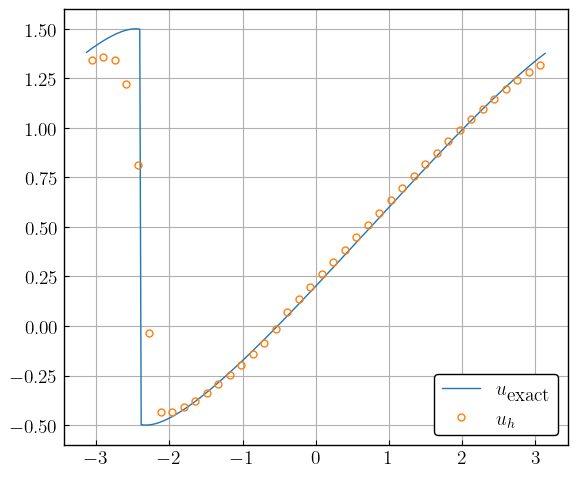

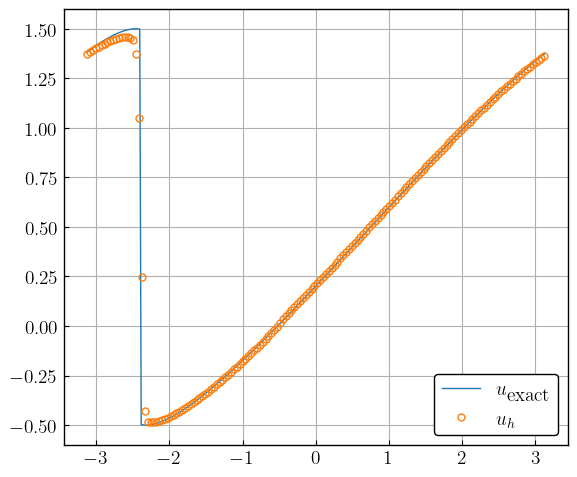

In [19]:
# DG P0
config = {
    "k": 0,
    "init": burgers_init,
    "exact": burgers_exact,
    "xleft": -np.pi,
    "xright": np.pi,
    "f": burgers_f,
    "df": burgers_df,
    "fhat": get_LF_flux(burgers_f, burgers_get_alpha),
}

order_test(tend=0.5, nlist=np.array([20, 40, 80, 160, 320]), **config)
shock_test(tend=1.5, nlist=np.array([40, 160]), n_ref=320, **config)

  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 20  2.35e-02       NaN  1.48e-02       NaN    3.07e-02         NaN
 40  6.03e-03  1.96e+00  3.95e-03  1.91e+00    9.02e-03    1.77e+00
 80  1.53e-03  1.98e+00  1.04e-03  1.93e+00    2.41e-03    1.90e+00
160  3.89e-04  1.98e+00  2.68e-04  1.95e+00    6.26e-04    1.94e+00
320  9.86e-05  1.98e+00  6.84e-05  1.97e+00    1.59e-04    1.98e+00


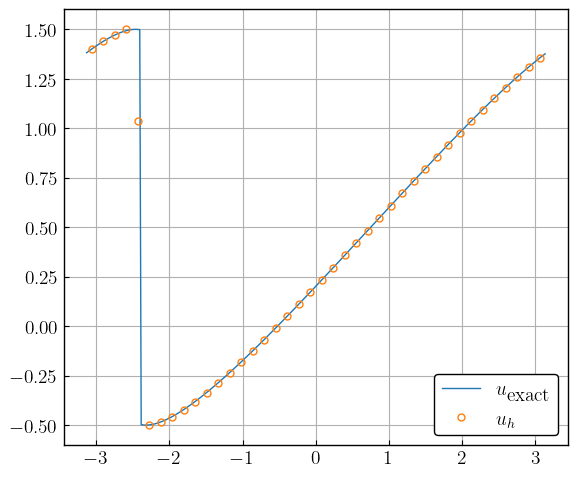

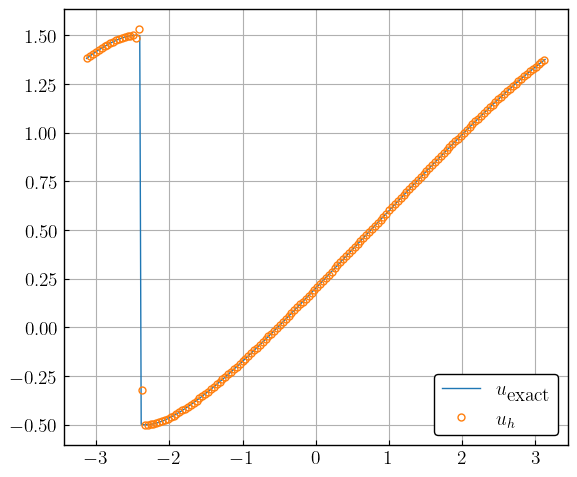

In [20]:
# DG P1
config = {
    "k": 1,
    "init": burgers_init,
    "exact": burgers_exact,
    "xleft": -np.pi,
    "xright": np.pi,
    "f": burgers_f,
    "df": burgers_df,
    "fhat": get_LF_flux(burgers_f,burgers_get_alpha),
}

order_test(tend=0.5, nlist=np.array([20, 40, 80, 160, 320]), **config)
shock_test(tend=1.5, nlist=np.array([40, 160]), n_ref=320, **config)

  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 20  1.26e-03       NaN  1.02e-03       NaN    3.59e-03         NaN
 40  1.63e-04  2.95e+00  1.41e-04  2.86e+00    5.75e-04    2.64e+00
 80  2.08e-05  2.98e+00  1.89e-05  2.90e+00    8.23e-05    2.81e+00
160  2.63e-06  2.98e+00  2.47e-06  2.94e+00    1.13e-05    2.86e+00
320  3.32e-07  2.99e+00  3.16e-07  2.96e+00    1.49e-06    2.92e+00


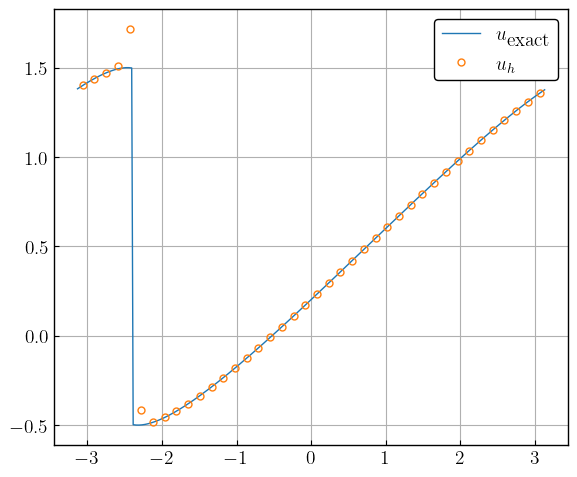

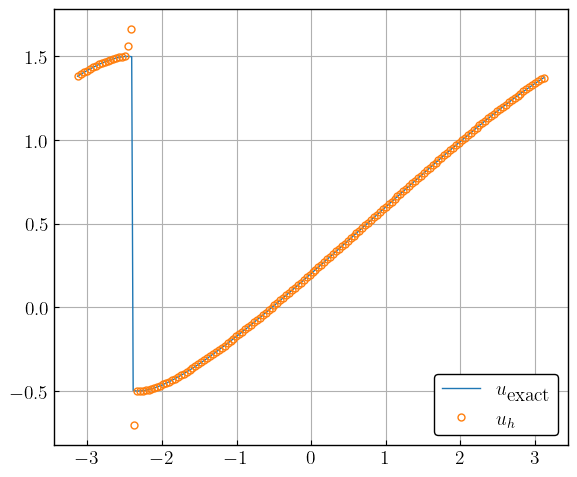

In [21]:
# DG P2
config = {
    "k": 2,
    "init": burgers_init,
    "exact": burgers_exact,
    "xleft": -np.pi,
    "xright": np.pi,
    "f": burgers_f,
    "df": burgers_df,
    "fhat": get_LF_flux(burgers_f, burgers_get_alpha),
}

order_test(tend=0.5, nlist=np.array([20, 40, 80, 160, 320]), **config)
shock_test(tend=1.5, nlist=np.array([40, 160]), n_ref=320, **config)

  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 20  7.93e-02       NaN  5.23e-02       NaN    5.80e-02         NaN
 40  1.94e-02  2.03e+00  1.64e-02  1.68e+00    2.32e-02    1.32e+00
 80  4.30e-03  2.17e+00  4.63e-03  1.82e+00    8.28e-03    1.49e+00
160  9.08e-04  2.24e+00  1.28e-03  1.85e+00    3.09e-03    1.42e+00
320  1.86e-04  2.29e+00  3.47e-04  1.89e+00    1.13e-03    1.46e+00


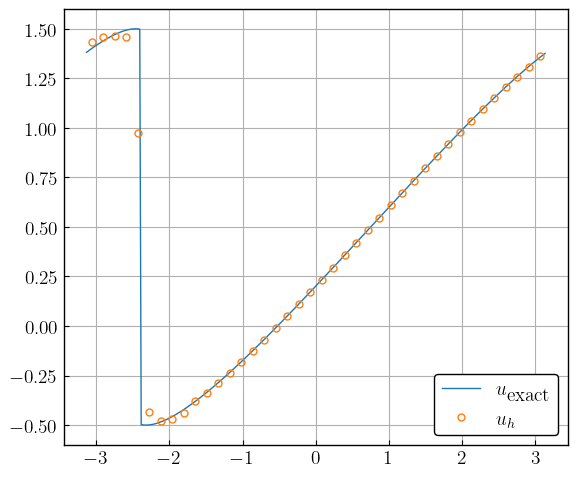

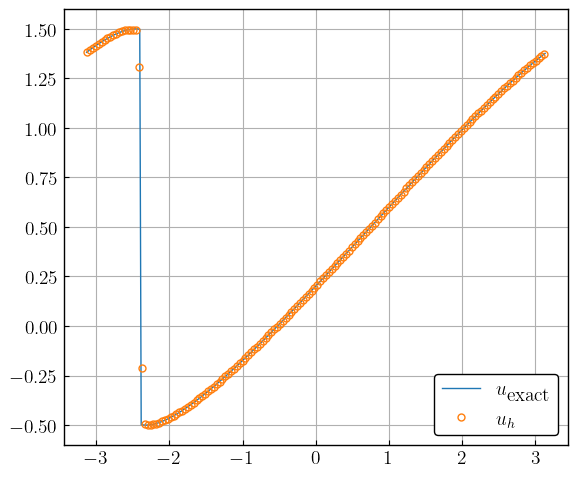

In [22]:
# DG P2 + TVD limiter
config = {
    "k": 2,
    "init": burgers_init,
    "exact": burgers_exact,
    "xleft": -np.pi,
    "xright": np.pi,
    "f": burgers_f,
    "df": burgers_df,
    "fhat": get_LF_flux(burgers_f, burgers_get_alpha),
    "lim": tvd(),
}

order_test(tend=0.5, nlist=np.array([20, 40, 80, 160, 320]), **config)
shock_test(tend=1.5, nlist=np.array([40, 160]), n_ref=320, **config)

  m  L1 error  L1 order  L2 error  L2 order  Linf error  Linf order
 20  1.26e-03       NaN  1.02e-03       NaN    3.59e-03         NaN
 40  1.63e-04  2.95e+00  1.41e-04  2.86e+00    5.75e-04    2.64e+00
 80  2.08e-05  2.98e+00  1.89e-05  2.90e+00    8.23e-05    2.81e+00
160  2.63e-06  2.98e+00  2.47e-06  2.94e+00    1.13e-05    2.86e+00
320  3.32e-07  2.99e+00  3.16e-07  2.96e+00    1.49e-06    2.92e+00


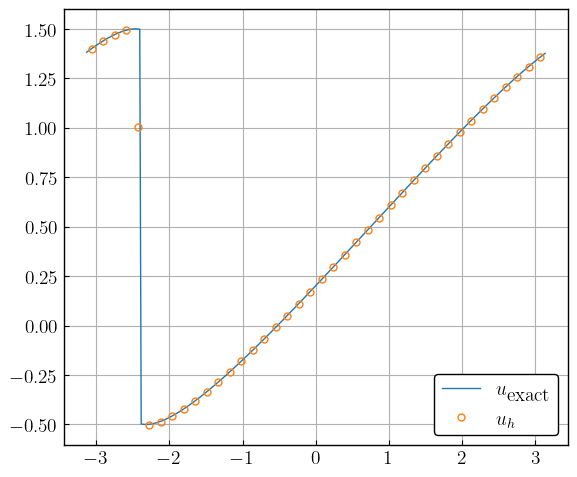

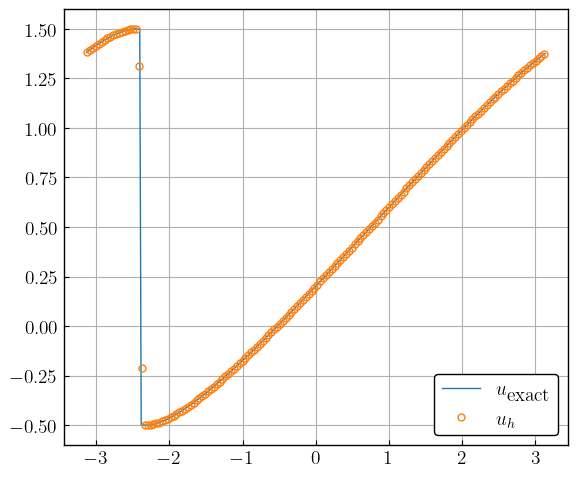

In [23]:
# DG P2 + TVB limiter (M=5)
config = {
    "k": 2,
    "init": burgers_init,
    "exact": burgers_exact,
    "xleft": -np.pi,
    "xright": np.pi,
    "f": burgers_f,
    "df": burgers_df,
    "fhat": get_LF_flux(burgers_f,burgers_get_alpha),
    "lim": tvb(5),
}

order_test(tend=0.5, nlist=np.array([20, 40, 80, 160, 320]), **config)
shock_test(tend=1.5, nlist=np.array([40, 160]), n_ref=320, **config)